# Exploring Feature Distributions from Pedestrian Trajectories

This notebook extracts scalar features from trajectory JSON data and explores their distributions.  
The goal is to identify which probability families best describe pedestrian movement — forming the basis for the statistical manifold in Article 4.

**Data:** `output/trajectory/*_analysis_wgs84.json`  
**Target video (Article 3):** `VID20260202183314`

In [5]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import vonmises, lognorm, expon, beta
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 1. Load Data

In [6]:
DATA_DIR = Path('../output/trajectory')
TARGET_VIDEO = 'VID20260202183314'

with open(DATA_DIR / f'{TARGET_VIDEO}_analysis_wgs84.json') as f:
    data = json.load(f)

tracks = data['tracks']
fps = data['fps']
print(f'Video: {data["video_name"]}')
print(f'FPS: {fps}')
print(f'Total tracks: {len(tracks)}')

Video: VID20260202183314.mp4
FPS: 29
Total tracks: 1061


## 2. Feature Extraction

For each trajectory, compute:
- **speed_mean, speed_max, speed_std** — walking pace statistics
- **dir_mean_deg, dir_kappa** — circular direction statistics (von Mises)
- **accel_mean_abs** — mean absolute acceleration
- **straightness** — displacement / path_length
- **duration_sec** — total observed time

In [7]:
def haversine_m(lon1, lat1, lon2, lat2):
    """Distance between two WGS84 points in meters."""
    R = 6371000
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def bearing_deg(lon1, lat1, lon2, lat2):
    """Bearing from point 1 to point 2 in degrees [0, 360)."""
    dlon = np.radians(lon2 - lon1)
    lat1r, lat2r = np.radians(lat1), np.radians(lat2)
    x = np.sin(dlon) * np.cos(lat2r)
    y = np.cos(lat1r)*np.sin(lat2r) - np.sin(lat1r)*np.cos(lat2r)*np.cos(dlon)
    return (np.degrees(np.arctan2(x, y)) + 360) % 360


def extract_features(track, min_points=3):
    """Extract scalar features from a single trajectory. Returns None if too short."""
    traj = track.get('trajectory_wgs84', [])
    if len(traj) < min_points:
        return None

    lons = np.array([p['lon'] for p in traj])
    lats = np.array([p['lat'] for p in traj])
    times = np.array([p['time_sec'] for p in traj])

    # --- speed ---
    dists = np.array([
        haversine_m(lons[i], lats[i], lons[i+1], lats[i+1])
        for i in range(len(lons)-1)
    ])
    dts = np.diff(times)
    dts = np.where(dts < 1e-6, 1e-6, dts)  # avoid division by zero
    speeds = dists / dts

    speed_mean = float(np.mean(speeds))
    speed_max  = float(np.max(speeds))
    speed_std  = float(np.std(speeds))

    # --- direction (circular) ---
    bearings = np.array([
        bearing_deg(lons[i], lats[i], lons[i+1], lats[i+1])
        for i in range(len(lons)-1)
    ])
    bearings_rad = np.radians(bearings)
    mean_sin = np.mean(np.sin(bearings_rad))
    mean_cos = np.mean(np.cos(bearings_rad))
    dir_mean_deg = float((np.degrees(np.arctan2(mean_sin, mean_cos)) + 360) % 360)
    R_bar = np.sqrt(mean_sin**2 + mean_cos**2)  # mean resultant length [0,1]
    # approximate kappa from R_bar (Mardia & Jupp)
    if R_bar < 0.53:
        kappa = 2*R_bar + R_bar**3 + 5/6 * R_bar**5
    elif R_bar < 0.85:
        kappa = -0.4 + 1.39*R_bar + 0.43/(1-R_bar)
    else:
        kappa = 1 / (R_bar**3 - 4*R_bar**2 + 3*R_bar)
    dir_kappa = float(kappa)

    # --- acceleration ---
    dts2 = (dts[:-1] + dts[1:]) / 2
    dts2 = np.where(dts2 < 1e-6, 1e-6, dts2)
    accels = np.abs(np.diff(speeds)) / dts2
    accel_mean_abs = float(np.mean(accels)) if len(accels) > 0 else 0.0

    # --- straightness ---
    total_dist = float(np.sum(dists))
    displacement = haversine_m(lons[0], lats[0], lons[-1], lats[-1])
    straightness = float(displacement / total_dist) if total_dist > 1e-6 else 1.0

    # --- duration ---
    duration_sec = float(times[-1] - times[0])

    return {
        'id': track['id'],
        'speed_mean': speed_mean,
        'speed_max': speed_max,
        'speed_std': speed_std,
        'dir_mean_deg': dir_mean_deg,
        'dir_kappa': dir_kappa,
        'accel_mean_abs': accel_mean_abs,
        'straightness': straightness,
        'duration_sec': duration_sec,
        'n_points': len(traj),
    }


records = [extract_features(t) for t in tracks]
records = [r for r in records if r is not None]
df = pd.DataFrame(records)

print(f'Tracks after filtering: {len(df)}')
df.describe()

Tracks after filtering: 861


,id,speed_mean,speed_max,speed_std,dir_mean_deg,dir_kappa,accel_mean_abs,straightness,duration_sec,n_points
count,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000
mean,738.149826,20.674314,139.328493,25.800877,126.889202,0.427229,483.414263,0.199740,3.594574,66.462253
std,431.696644,11.993876,127.514948,21.302899,90.230684,1.644544,333.920181,0.186788,3.607618,70.043309
min,0.000000,1.526870,3.030860,0.462114,0.303812,0.004987,13.394617,0.000000,0.069000,3.000000
25%,353.000000,13.631751,57.577036,13.545074,63.398429,0.201818,303.689455,0.065084,1.241000,21.000000
50%,746.000000,17.936435,100.117524,20.099994,98.144397,0.295482,415.190135,0.134662,2.517000,44.000000
75%,1096.000000,24.817164,168.821888,30.876414,173.018265,0.438226,560.786804,0.274120,4.655000,86.000000
max,1481.000000,125.635070,896.112934,206.009274,359.577439,45.647670,4466.419652,0.998885,28.827000,602.000000


## 3. Speed Distributions

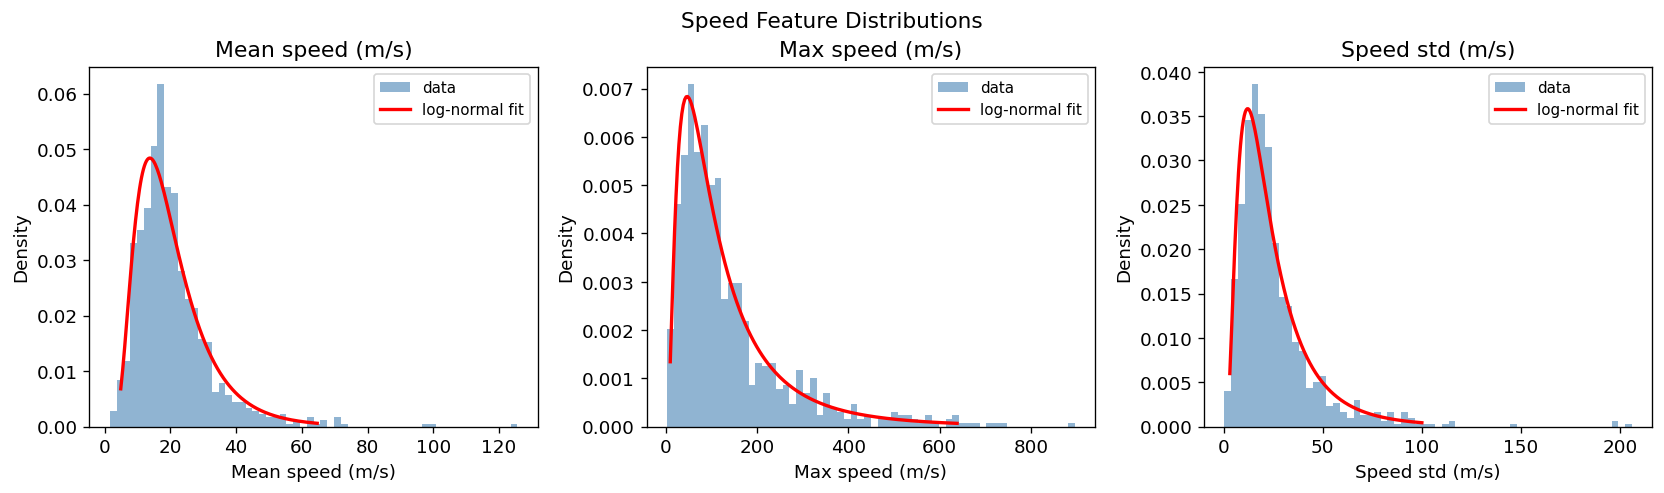

Median mean speed: 17.94 m/s
95th percentile mean speed: 42.17 m/s


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label in zip(axes,
    ['speed_mean', 'speed_max', 'speed_std'],
    ['Mean speed (m/s)', 'Max speed (m/s)', 'Speed std (m/s)']):

    data_col = df[col].dropna()
    data_col = data_col[data_col > 0]

    ax.hist(data_col, bins=60, density=True, alpha=0.6, color='steelblue', label='data')

    # Fit log-normal
    shape, loc, scale = lognorm.fit(data_col, floc=0)
    x = np.linspace(data_col.quantile(0.01), data_col.quantile(0.99), 200)
    ax.plot(x, lognorm.pdf(x, shape, loc, scale), 'r-', lw=2, label='log-normal fit')

    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.set_title(label)

plt.tight_layout()
plt.suptitle('Speed Feature Distributions', y=1.02, fontsize=13)
plt.show()

print(f'Median mean speed: {df["speed_mean"].median():.2f} m/s')
print(f'95th percentile mean speed: {df["speed_mean"].quantile(0.95):.2f} m/s')

## 4. Direction Distribution (Circular)

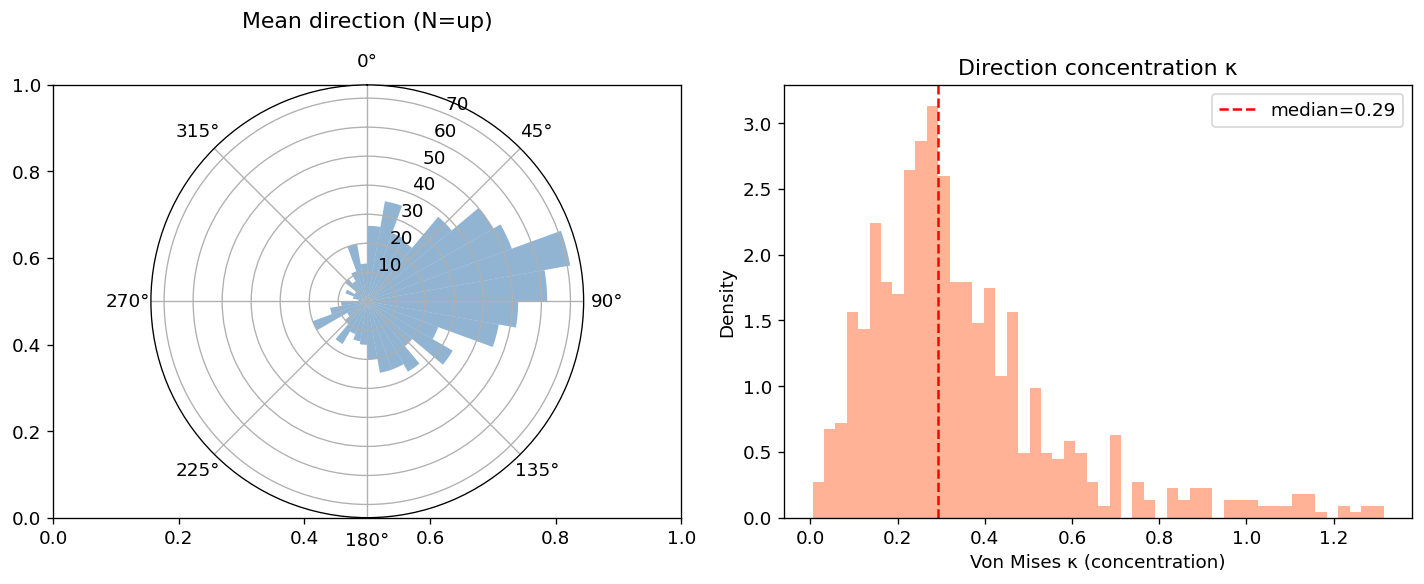

Dominant direction: 0.3°
Median κ: 0.30


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Polar histogram of mean directions ---
ax_polar = plt.subplot(121, projection='polar')
dir_rad = np.radians(df['dir_mean_deg'].dropna())
bins = np.linspace(0, 2*np.pi, 37)
counts, _ = np.histogram(dir_rad, bins=bins)
bar_centers = (bins[:-1] + bins[1:]) / 2
ax_polar.bar(bar_centers, counts, width=np.diff(bins), alpha=0.6, color='steelblue')
ax_polar.set_theta_zero_location('N')
ax_polar.set_theta_direction(-1)
ax_polar.set_title('Mean direction (N=up)', pad=15)

# --- Kappa distribution ---
ax2 = plt.subplot(122)
kappa_vals = df['dir_kappa'].dropna()
kappa_vals = kappa_vals[kappa_vals < kappa_vals.quantile(0.99)]  # clip outliers
ax2.hist(kappa_vals, bins=50, density=True, alpha=0.6, color='coral')
ax2.set_xlabel('Von Mises κ (concentration)')
ax2.set_ylabel('Density')
ax2.set_title('Direction concentration κ')
ax2.axvline(kappa_vals.median(), color='r', linestyle='--', label=f'median={kappa_vals.median():.2f}')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'Dominant direction: {df["dir_mean_deg"].mode()[0]:.1f}°')
print(f'Median κ: {df["dir_kappa"].median():.2f}')

## 5. Acceleration Distribution

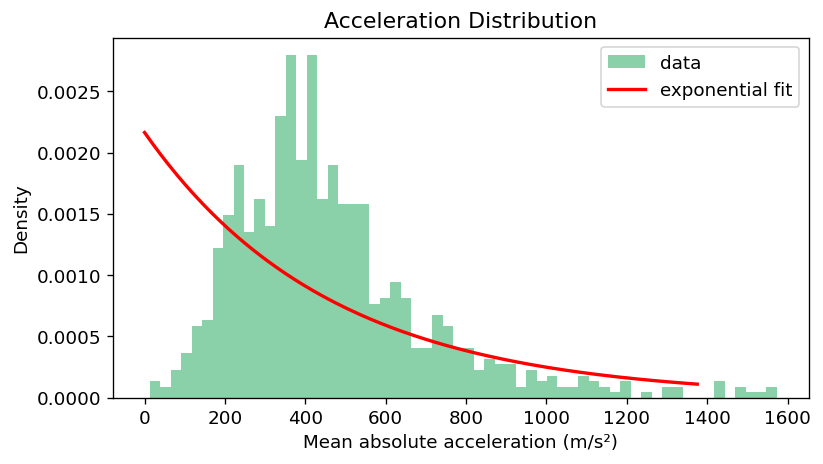

Median abs. acceleration: 415.190 m/s²


In [18]:
fig, ax = plt.subplots(figsize=(7, 4))

accel = df['accel_mean_abs'].dropna()
accel = accel[accel < accel.quantile(0.99)]  # clip heavy tail for visualization

ax.hist(accel, bins=60, density=True, alpha=0.6, color='mediumseagreen', label='data')

# Fit exponential
loc_e, scale_e = expon.fit(accel, floc=0)
x = np.linspace(0, accel.quantile(0.99), 200)
ax.plot(x, expon.pdf(x, loc_e, scale_e), 'r-', lw=2, label='exponential fit')

ax.set_xlabel('Mean absolute acceleration (m/s²)')
ax.set_ylabel('Density')
ax.set_title('Acceleration Distribution')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Median abs. acceleration: {df["accel_mean_abs"].median():.3f} m/s²')

## 6. Path Straightness Distribution

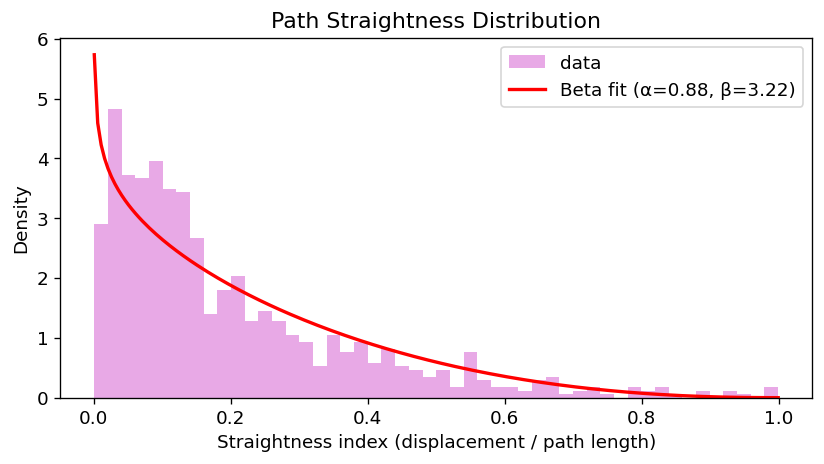

Median straightness: 0.135
Fraction with straightness > 0.9: 0.7%
Fraction with straightness < 0.5: 91.6%


In [19]:
fig, ax = plt.subplots(figsize=(7, 4))

straight = df['straightness'].dropna().clip(0.001, 0.999)  # beta requires (0,1)

ax.hist(straight, bins=50, density=True, alpha=0.6, color='orchid', label='data')

# Fit beta distribution
a_b, b_b, loc_b, scale_b = beta.fit(straight, floc=0, fscale=1)
x = np.linspace(0.001, 0.999, 200)
ax.plot(x, beta.pdf(x, a_b, b_b, loc_b, scale_b), 'r-', lw=2,
        label=f'Beta fit (α={a_b:.2f}, β={b_b:.2f})')

ax.set_xlabel('Straightness index (displacement / path length)')
ax.set_ylabel('Density')
ax.set_title('Path Straightness Distribution')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Median straightness: {straight.median():.3f}')
print(f'Fraction with straightness > 0.9: {(straight > 0.9).mean():.1%}')
print(f'Fraction with straightness < 0.5: {(straight < 0.5).mean():.1%}')

## 7. Duration Distribution

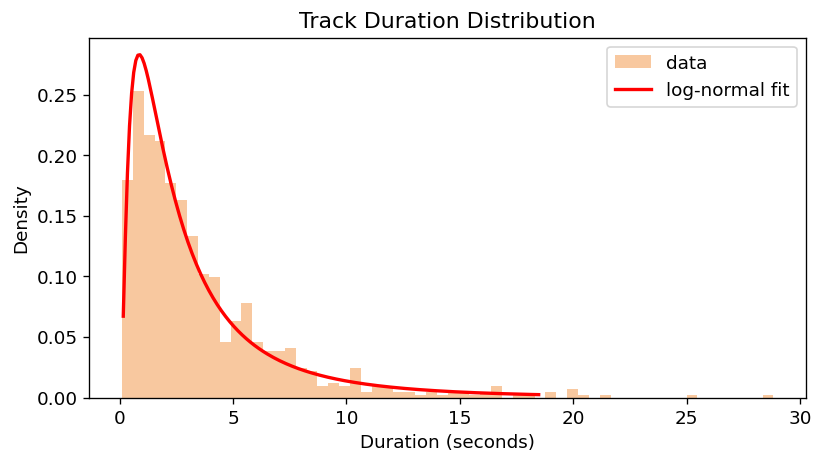

Median duration: 2.5 s
90th percentile: 7.7 s


In [20]:
fig, ax = plt.subplots(figsize=(7, 4))

dur = df['duration_sec'].dropna()
dur = dur[dur > 0.1]

ax.hist(dur, bins=60, density=True, alpha=0.6, color='sandybrown', label='data')

# Fit log-normal
shape_d, loc_d, scale_d = lognorm.fit(dur, floc=0)
x = np.linspace(dur.quantile(0.01), dur.quantile(0.99), 200)
ax.plot(x, lognorm.pdf(x, shape_d, loc_d, scale_d), 'r-', lw=2, label='log-normal fit')

ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Density')
ax.set_title('Track Duration Distribution')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Median duration: {dur.median():.1f} s')
print(f'90th percentile: {dur.quantile(0.9):.1f} s')

## 8. Goodness-of-Fit Tests

Kolmogorov-Smirnov test for each feature vs. the hypothesized distribution.

In [21]:
results = []

# Speed mean — log-normal
s = df['speed_mean'].dropna()
s = s[s > 0]
sh, lo, sc = lognorm.fit(s, floc=0)
stat, p = stats.kstest(s, lambda x: lognorm.cdf(x, sh, lo, sc))
results.append({'feature': 'speed_mean', 'distribution': 'log-normal', 'KS stat': round(stat,4), 'p-value': round(p,4)})

# Acceleration — exponential
a = df['accel_mean_abs'].dropna()
a = a[a > 0]
lo_e, sc_e = expon.fit(a, floc=0)
stat, p = stats.kstest(a, lambda x: expon.cdf(x, lo_e, sc_e))
results.append({'feature': 'accel_mean_abs', 'distribution': 'exponential', 'KS stat': round(stat,4), 'p-value': round(p,4)})

# Straightness — beta
st = df['straightness'].dropna().clip(0.001, 0.999)
a_b, b_b, lo_b, sc_b = beta.fit(st, floc=0, fscale=1)
stat, p = stats.kstest(st, lambda x: beta.cdf(x, a_b, b_b, lo_b, sc_b))
results.append({'feature': 'straightness', 'distribution': 'beta', 'KS stat': round(stat,4), 'p-value': round(p,4)})

# Duration — log-normal
d = df['duration_sec'].dropna()
d = d[d > 0]
sh_d, lo_d, sc_d = lognorm.fit(d, floc=0)
stat, p = stats.kstest(d, lambda x: lognorm.cdf(x, sh_d, lo_d, sc_d))
results.append({'feature': 'duration_sec', 'distribution': 'log-normal', 'KS stat': round(stat,4), 'p-value': round(p,4)})

pd.DataFrame(results)

,feature,distribution,KS stat,p-value
0,speed_mean,log-normal,0.0499,0.0267
1,accel_mean_abs,exponential,0.2519,0.0000
2,straightness,beta,0.0891,0.0000
3,duration_sec,log-normal,0.0462,0.0494


## 9. Feature Correlation Overview

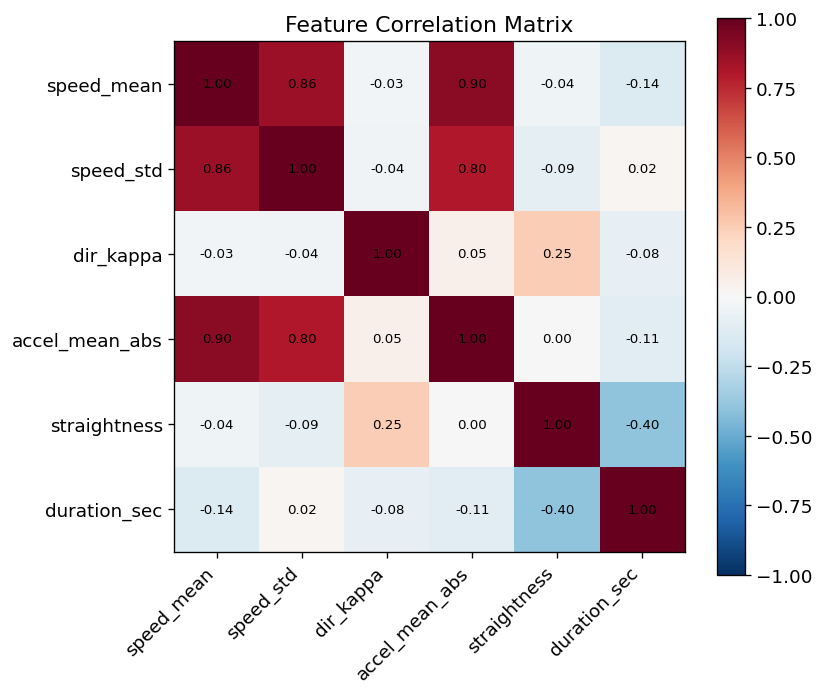

In [22]:
import matplotlib.cm as cm

features = ['speed_mean', 'speed_std', 'dir_kappa', 'accel_mean_abs', 'straightness', 'duration_sec']
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha='right')
ax.set_yticklabels(features)
for i in range(len(features)):
    for j in range(len(features)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 10. Summary: Distribution Hypotheses

| Feature | Distribution family | Rationale |
|---|---|---|
| `speed_mean` | Log-normal | Right-skewed, positive support |
| `dir_mean_deg` | Von Mises | Circular variable |
| `accel_mean_abs` | Exponential | Near-zero peak, positive support |
| `straightness` | Beta | Bounded [0,1], possibly bimodal |
| `duration_sec` | Log-normal | Heavy right tail, positive support |

These families are used in Article 4 to parameterize the statistical manifold.  
Each trajectory becomes a point in the product parameter space of these distributions.

In [1]:
# Save feature table for use in Article 4 notebook
out_path = Path('../output') / f'{TARGET_VIDEO}_features.csv'
df.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(f'Shape: {df.shape}')

NameError: name 'Path' is not defined